# Data parsing and exploration for learnedcache

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import numpy as np
import csv
import glob
from pathlib import Path

In [2]:
def read_csvs_to_dataframe(file_pattern: str) -> pd.DataFrame:
    """
    Reads multiple CSV files and concatenates them into a single dataframe.
    Adds a trial_id column based on the sequence in which files are loaded.
    """
    filepaths = glob.glob(file_pattern)
    dataframes = []
    for trial_id, filepath in enumerate(filepaths):
        df = pd.read_csv(filepath)
        df['trial_id'] = trial_id
        dataframes.append(df)
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    return combined_df


In [ ]:
df = read_csvs_to_dataframe('data/fileserver/*access.csv')

In [4]:
df.head()

,a,t,d,i,o,s,z,f,trial_id
0,358925815532991,1469662196,253:0,786436,0,0,181829504,1000,0
1,358925815616598,1469743088,253:0,786436,1,1,181829504,1000,0
2,358925815618421,1469742095,253:0,786436,2,1,181829504,1000,0
3,358925815620405,1469741425,253:0,786436,3,1,181829504,1000,0
4,358925815621826,1469740000,253:0,786436,4,1,181829504,1000,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12902256 entries, 0 to 12902255
Data columns (total 9 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   a         int64 
 1   t         int64 
 2   d         object
 3   i         int64 
 4   o         int64 
 5   s         int64 
 6   z         int64 
 7   f         int64 
 8   trial_id  int64 
dtypes: int64(8), object(1)
memory usage: 885.9+ MB


In [6]:
pd.set_option('display.precision', 5)
df.describe()

,a,t,i,o,s,z,f,trial_id
count,1.29023e+07,1.29023e+07,1.29023e+07,1.29023e+07,1.29023e+07,1.29023e+07,1.29023e+07,12902256.0
mean,3.58957e+14,6.58437e+08,9.22062e+05,2.64285e+01,9.95979e-01,2.18664e+05,1.49870e+03,0.0
std,1.73229e+10,6.04557e+08,2.32448e+03,4.42132e+01,6.32825e-02,3.23145e+05,6.04894e+02,0.0
min,3.58926e+14,1.55320e+07,7.86436e+05,0.00000e+00,0.00000e+00,2.44000e+02,1.00000e+03,0.0
25%,3.58942e+14,3.51385e+08,9.20059e+05,8.00000e+00,1.00000e+00,1.19893e+05,1.00000e+03,0.0
50%,3.58957e+14,4.42999e+08,9.22062e+05,2.00000e+01,1.00000e+00,1.91916e+05,1.00000e+03,0.0
75%,3.58972e+14,8.51027e+08,9.24064e+05,3.70000e+01,1.00000e+00,2.87401e+05,1.81600e+03,0.0
max,3.58987e+14,1.72330e+10,9.26077e+05,3.40630e+04,1.00000e+00,1.81830e+08,4.71500e+03,0.0


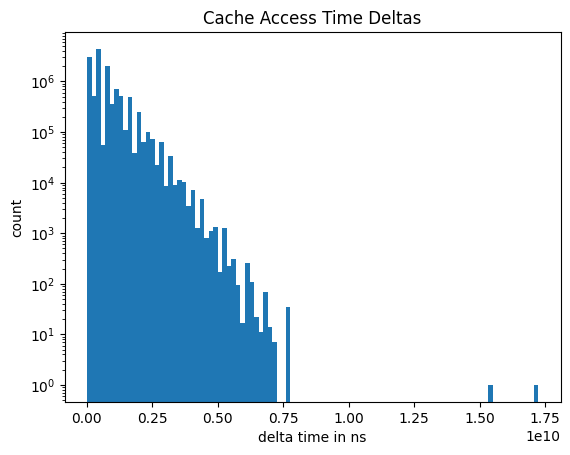

In [7]:
df['t'].plot(title='Cache Access Time Deltas', ylabel='count', xlabel="delta time in ns", kind='hist', bins=100)
plt.yscale('log')
plt.show()

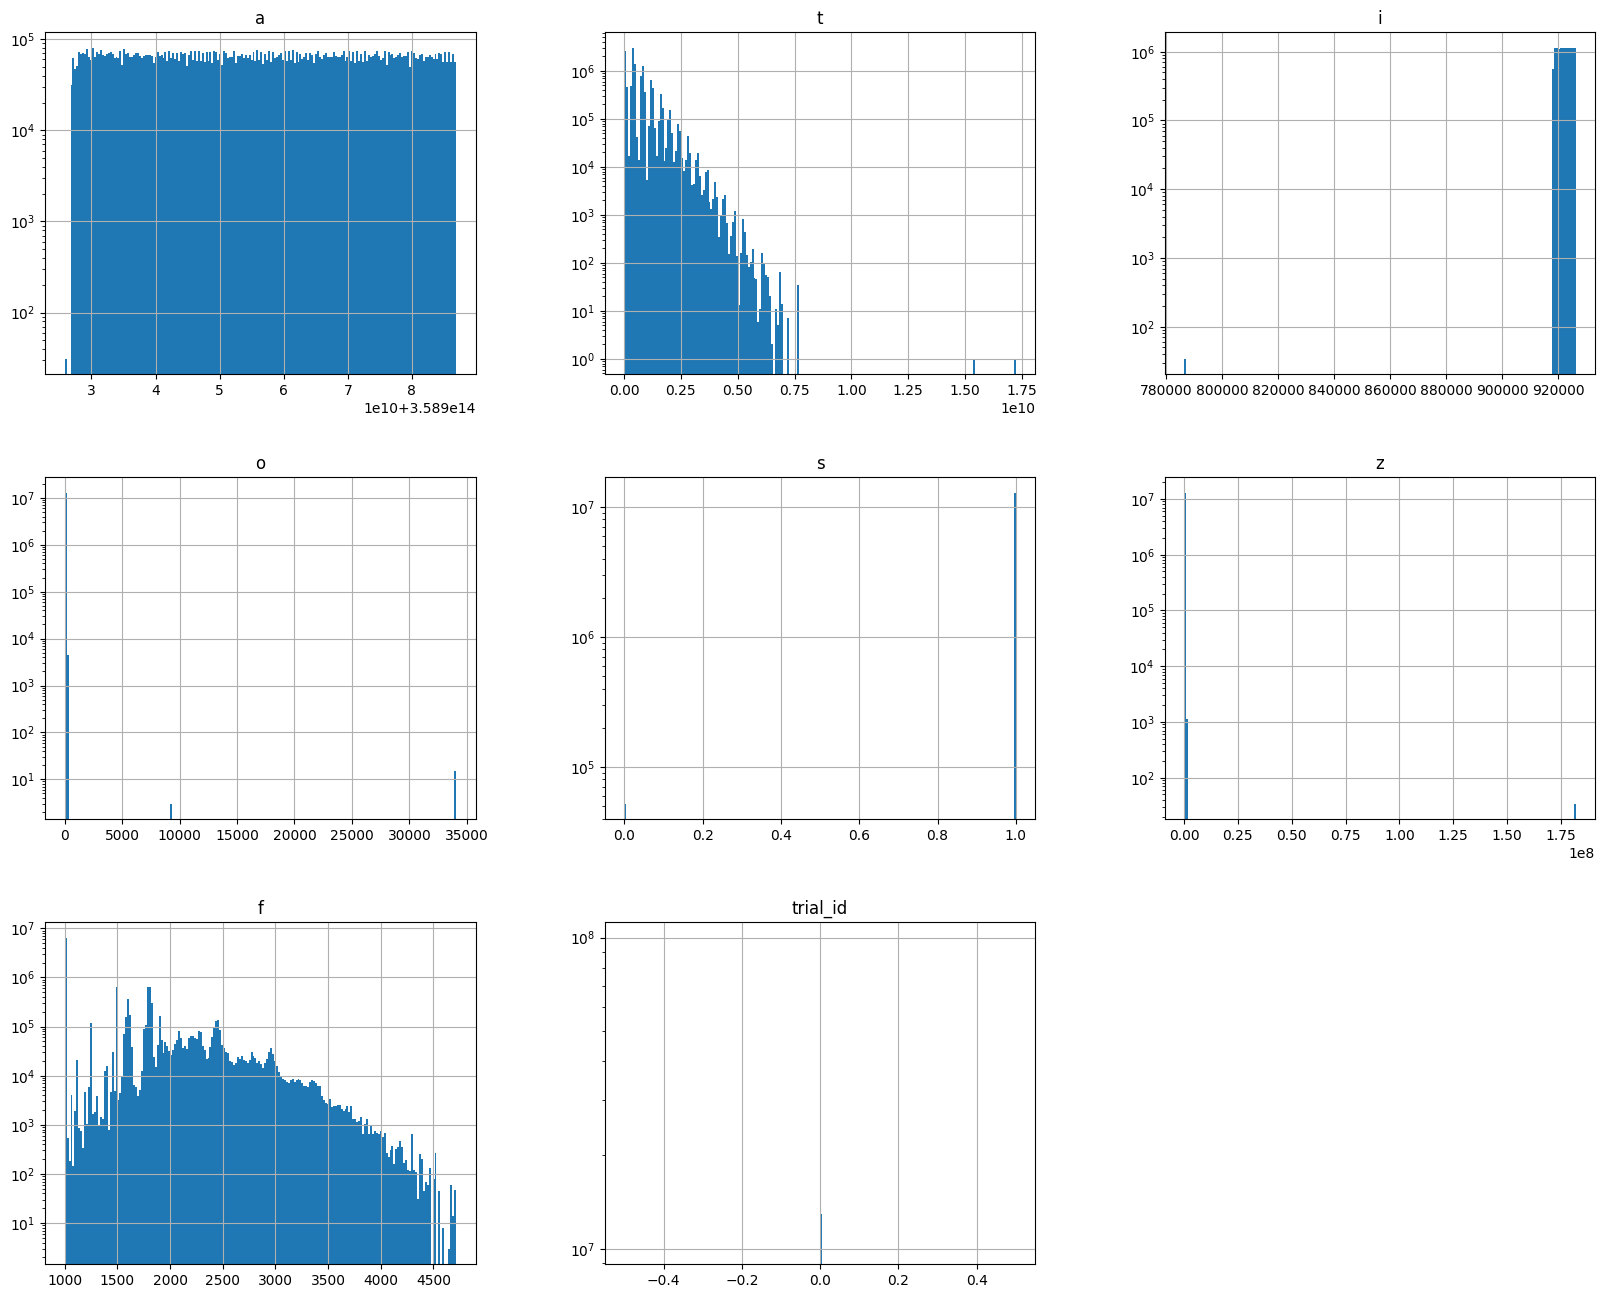

In [8]:
df.hist(figsize=(20,16), bins=200, log=True)
plt.show()

In [9]:
def train_and_transform_discretizer(
    X_train: pd.DataFrame,
    n_bins: int = 5,
    encode: str = 'ordinal',
    strategy: str = 'quantile',
    subsample: int | None = None,
    random_state: int | None = None
) -> tuple[pd.DataFrame, KBinsDiscretizer]:
    """
    Train a KBinsDiscretizer on the training dataset and return the transformed dataframe.
    
    Parameters
    ----------
    X_train : pd.DataFrame
        Training dataset to fit and transform
    n_bins : int, default=5
        Number of bins to produce. Must be >= 2.
    encode : {'onehot', 'onehot-dense', 'ordinal'}, default='ordinal'
        Method used to encode the transformed result.
        - 'onehot': Encode the transformed result with one-hot encoding
        - 'onehot-dense': Same as 'onehot' but returns dense array
        - 'ordinal': Return the bin identifier encoded as an integer value
    strategy : {'uniform', 'quantile', 'kmeans'}, default='quantile'
        Strategy used to define the widths of the bins.
        - 'uniform': All bins have identical widths
        - 'quantile': All bins have the same number of points
        - 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster
    subsample : int or None, default=None
        Maximum number of samples used to fit the model. If None, all samples are used.
    random_state : int or None, default=None
        Random state for reproducibility when using 'kmeans' strategy.
    
    Returns
    -------
    tuple[pd.DataFrame, KBinsDiscretizer]
        A tuple containing:
        - Transformed dataframe with discretized values
        - Fitted KBinsDiscretizer object for future transformations
    
    Examples
    --------
    >>> import pandas as pd
    >>> X_train = pd.DataFrame({'feature1': [1, 2, 3, 4, 5], 'feature2': [10, 20, 30, 40, 50]})
    >>> X_transformed, discretizer = train_and_transform_discretizer(X_train, n_bins=3)
    >>> print(X_transformed)
    """
    discretizer = KBinsDiscretizer(
        n_bins=n_bins,
        encode=encode,
        strategy=strategy,
        subsample=subsample,
        random_state=random_state,
        quantile_method='averaged_inverted_cdf',
    )

    X_transformed = discretizer.fit_transform(X_train)
    
    X_transformed_df = pd.DataFrame(
        X_transformed,
        columns=X_train.columns,
        index=X_train.index
    )
    
    return X_transformed_df, discretizer


In [10]:
featureset_df, discretizer = train_and_transform_discretizer(df[['t', 'z', 'f']], n_bins=10, strategy='quantile')
featureset_df.describe()

/Users/jef/research/learnedcache/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(


,t,z,f
count,1.29023e+07,1.29023e+07,1.29023e+07
mean,4.50000e+00,4.50013e+00,1.00346e+00
std,2.87228e+00,2.87231e+00,1.41483e+00
min,0.00000e+00,0.00000e+00,0.00000e+00
25%,2.00000e+00,2.00000e+00,0.00000e+00
50%,4.50000e+00,5.00000e+00,0.00000e+00
75%,7.00000e+00,7.00000e+00,2.00000e+00
max,9.00000e+00,9.00000e+00,4.00000e+00


In [11]:
n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
n_bins_list

[10, 10, 5]

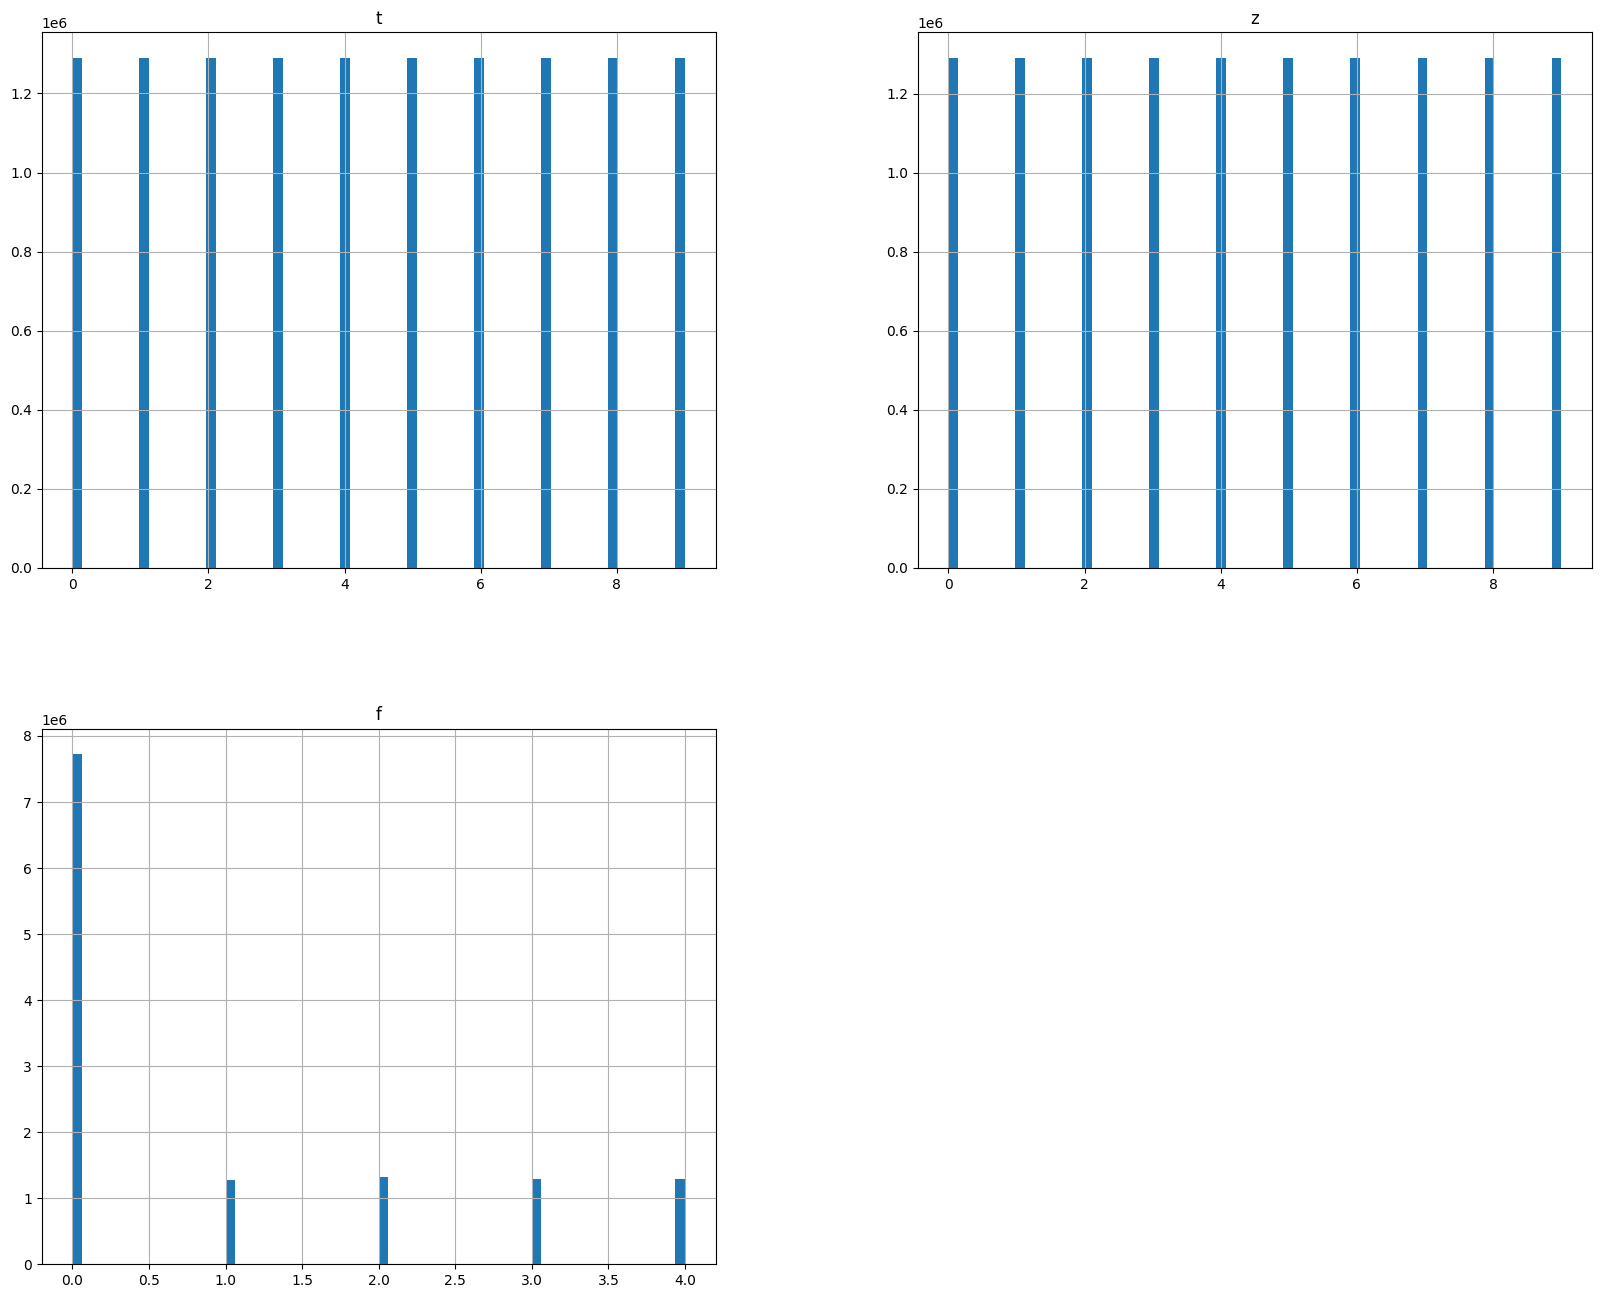

In [12]:
featureset_df.hist(figsize=(20,16), bins = 64)
plt.show()

In [13]:
X = pd.concat([featureset_df, df[['s', 'trial_id']]], axis=1)

In [14]:
Y = df.groupby(['trial_id', 'd', 'i', 'o'])['t'].shift(-1)

print(f"Label Statistics:")
print(f"Total rows: {len(Y)}")
print(f"Labeled rows: {Y.notna().sum()}")
print(f"Unlabeled rows (no future match): {Y.isna().sum()}")
print(f"Label coverage: {Y.notna().sum() / len(Y) * 100:.2f}%")

Label Statistics:
Total rows: 12902256
Labeled rows: 12085752
Unlabeled rows (no future match): 816504
Label coverage: 93.67%


In [15]:
Y.fillna(1e15, inplace=True)

In [16]:
N_CLASSES = 5
Y_binned, Y_discritizer = train_and_transform_discretizer(Y.to_frame(), n_bins=N_CLASSES, strategy='quantile')

array([[<Axes: title={'center': 't'}>]], dtype=object)

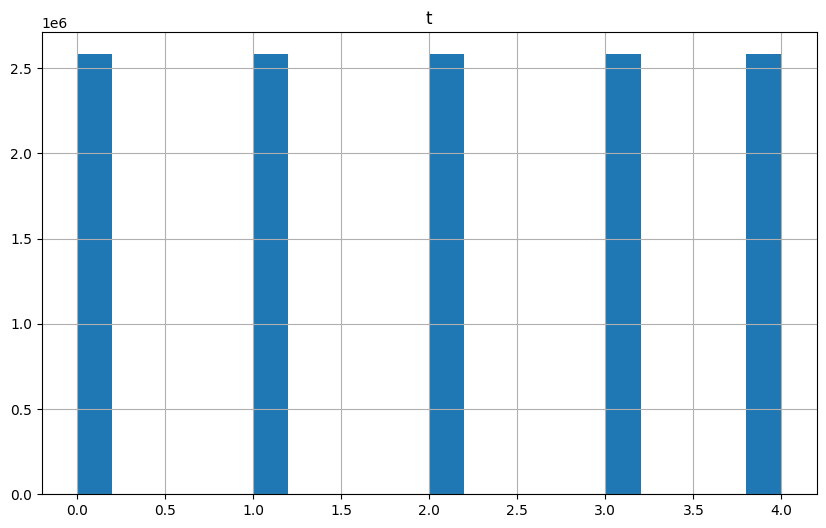

In [17]:
Y_binned.hist(figsize=(10,6), bins=20)

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binned, test_size=0.2, random_state=42, stratify=Y_binned
)

X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_features = X_train_np.shape[1]

print(f"\nData Summary:")
print(f"  Features: {n_features}")
print(f"  Classes: {N_CLASSES}")
print(f"  Training samples: {len(X_train_np)}")
print(f"  Test samples: {len(X_test_np)}")


Data Summary:
  Features: 5
  Classes: 5
  Training samples: 10321804
  Test samples: 2580452


In [19]:
import numpy as np
import keras
from keras import layers
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sys
sys.path.append('..')
from learnedcache.activations import Squaremax, TaylorSoftmax

In [20]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = Squaremax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_squaremax")

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_np, Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3)
ax3.set_title(f'Confusion Matrix\nAccuracy: {accuracy:.4f}')
ax3.set_ylabel('True Class')
ax3.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


Actual bins per feature: [10, 10, 5]


Model: "LearnedCache_squaremax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split (Split)       │ [(None, 3),       │          0 │ input_layer[0][0] │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 25)        │          0 │ split[0][0]       │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 27)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5)         │        140 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squaremax           │ (None, 5)         │          0 │ dense[0][0]       │
│ (Squaremax)         │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 140 (560.00 B)

 Trainable params: 140 (560.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
 55827/322557 ━━━━━━━━━━━━━━━━━━━━ 1:41 380us/step - accuracy: 0.2134 - loss: 4.3611

KeyboardInterrupt: 

Actual bins per feature: [9, 6, 8]


Model: "LearnedCache_taylorsoftmax"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_8 (Split)     │ [(None, 3),       │          0 │ input_layer_13[0… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 23)        │          0 │ split_8[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 25)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_8[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 5)         │        130 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ taylor_softmax_2    │ (None, 5)         │          0 │ dense_10[0][0]    │
│ (TaylorSoftmax)     │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130 (520.00 B)

 Trainable params: 130 (520.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 220s 415us/step - accuracy: 0.4876 - loss: 1.1873 - val_accuracy: 0.4934 - val_loss: 1.1892
Epoch 2/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 221s 417us/step - accuracy: 0.4886 - loss: 1.1884 - val_accuracy: 0.4860 - val_loss: 1.1856
Epoch 3/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 221s 417us/step - accuracy: 0.4887 - loss: 1.1892 - val_accuracy: 0.4968 - val_loss: 1.2079
Epoch 4/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 221s 418us/step - accuracy: 0.4890 - loss: 1.1895 - val_accuracy: 0.4922 - val_loss: 1.1811
Epoch 5/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 221s 417us/step - accuracy: 0.4887 - loss: 1.1885 - val_accuracy: 0.4917 - val_loss: 1.1836
Restoring model weights from the end of the best epoch: 4.

Test Accuracy: 0.4922
Trained for 5 epochs (early stopping)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.31      0.38    845460
         1.0       0.56      0.65      0.60    845461
        

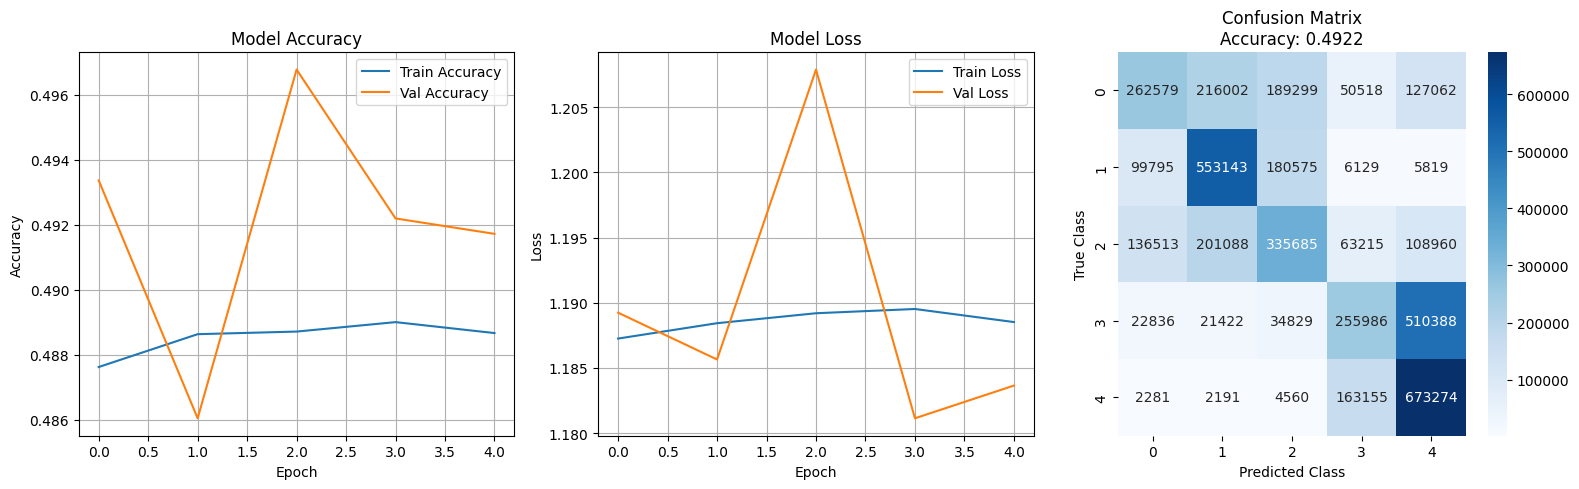

In [ ]:
from learnedcache.layers import FeatureOneHotEncoder
import keras.ops as ops

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print(f"Actual bins per feature: {n_bins_list}")

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized_features = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized_features)

combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(N_CLASSES)(combined)
output = TaylorSoftmax()(output)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_taylorsoftmax")

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

Y_pred_prob = model.predict(X_test_np, verbose=0)
Y_pred = np.argmax(Y_pred_prob, axis=1)
accuracy = accuracy_score(Y_test_np, Y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Trained for {len(history.history['loss'])} epochs (early stopping)")
print("\nClassification Report:")
print(classification_report(Y_test_np, Y_pred))

print("\nPer-Class Accuracy:")
for i in range(N_CLASSES):
    mask = Y_test_np == i
    if mask.sum() > 0:
        class_acc = (Y_pred[mask] == i).sum() / mask.sum()
        print(f"  Class {i}: {class_acc:.4f} ({mask.sum()} samples)")

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(history.history["accuracy"], label="Train Accuracy")
ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(history.history["loss"], label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, Y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()

n_bins_list: [9, 6, 8]


Model: "LearnedCache_binary_slp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_9 (Split)     │ [(None, 3),       │          0 │ input_layer_14[0… │
│                     │ (None, 2)]        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_one_hot_en… │ (None, 23)        │          0 │ split_9[0][0]     │
│ (FeatureOneHotEnco… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 25)        │          0 │ feature_one_hot_… │
│ (Concatenate)       │                   │            │ split_9[0][1]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         26 │ concatenate_11[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26 (104.00 B)

 Trainable params: 26 (104.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 262s 494us/step - AUC: 0.9025 - accuracy: 0.8632 - loss: 0.3719 - val_AUC: 0.9024 - val_accuracy: 0.8641 - val_loss: 0.3718
Epoch 2/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 263s 497us/step - AUC: 0.9027 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9028 - val_accuracy: 0.8638 - val_loss: 0.3718
Epoch 3/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 241s 455us/step - AUC: 0.9026 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9024 - val_accuracy: 0.8620 - val_loss: 0.3718
Epoch 4/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 241s 455us/step - AUC: 0.9026 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9026 - val_accuracy: 0.8638 - val_loss: 0.3718
Epoch 5/5
528413/528413 ━━━━━━━━━━━━━━━━━━━━ 243s 459us/step - AUC: 0.9027 - accuracy: 0.8633 - loss: 0.3716 - val_AUC: 0.9024 - val_accuracy: 0.8635 - val_loss: 0.3717
Restoring model weights from the end of the best epoch: 5.


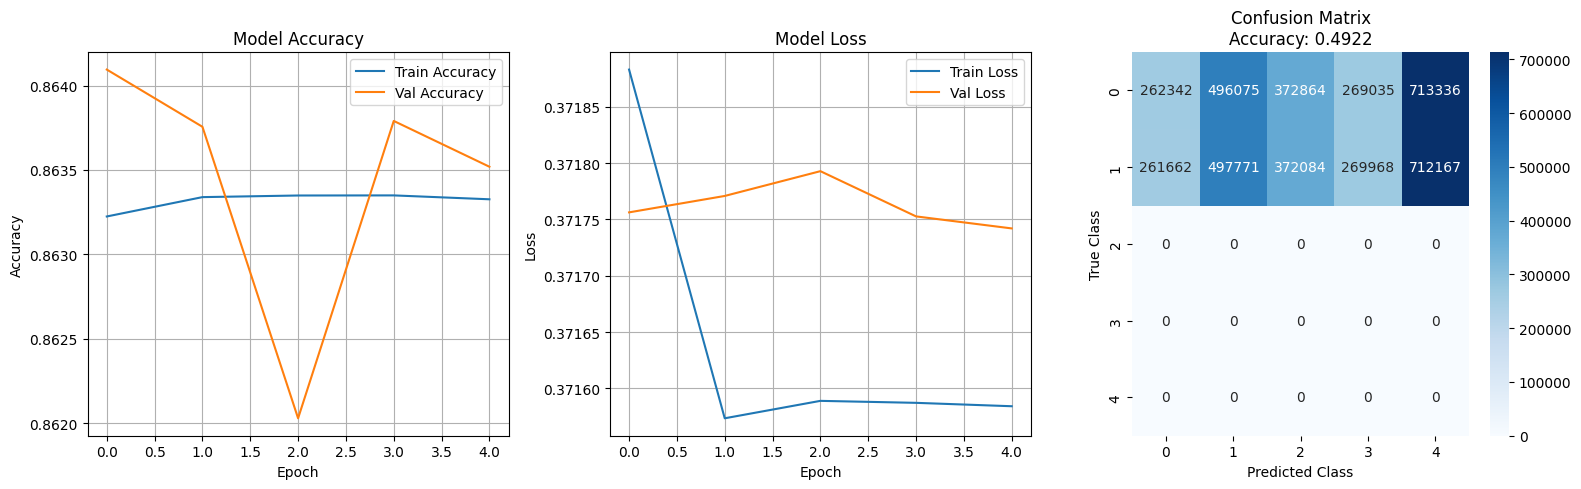

In [ ]:
Y_binary = (Y >= Y.quantile(0.5)).astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
Y_train_np = Y_train.to_numpy().ravel()
Y_test_np = Y_test.to_numpy().ravel()

n_bins_list = [len(discretizer.bin_edges_[i]) - 1 for i in range(3)]
print("n_bins_list:", n_bins_list)

from learnedcache.layers import FeatureOneHotEncoder
from keras import layers
from keras.callbacks import EarlyStopping
import keras

inputs = layers.Input(shape=(n_features,))

split_tensors = ops.split(inputs, [3], axis=1)
discretized = split_tensors[0]
other_features = split_tensors[1]

encoded = FeatureOneHotEncoder(n_bins_list)(discretized)
combined = layers.Concatenate()([encoded, other_features])

output = layers.Dense(1, activation="sigmoid")(combined)

model = keras.Model(inputs=inputs, outputs=output, name="LearnedCache_binary_slp")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", "AUC"])
model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
)

binary_history = model.fit(
    X_train_np,
    Y_train_np,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_np, Y_test_np),
    callbacks=[early_stop],
    verbose=1,
)

y_prob = model.predict(X_test_np, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(binary_history.history["accuracy"], label="Train Accuracy")
ax1.plot(binary_history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(binary_history.history["loss"], label="Train Loss")
ax2.plot(binary_history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()

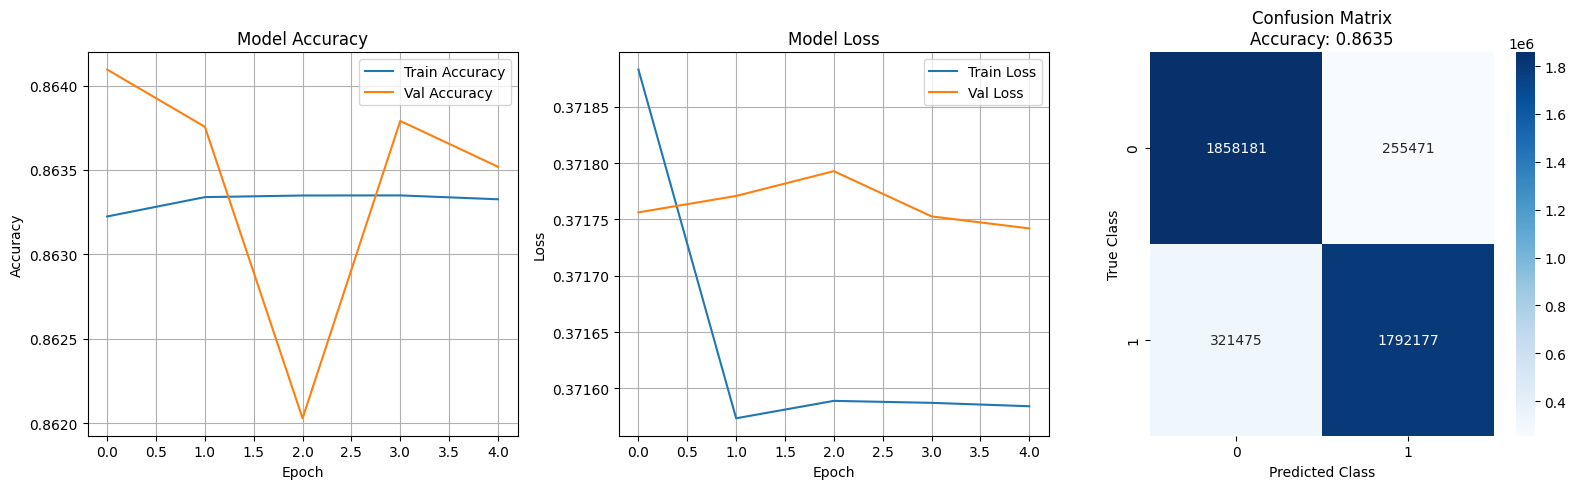

In [ ]:
accuracy = accuracy_score(Y_test_np, y_pred)

fig = plt.figure(figsize=(16, 5))

ax1 = plt.subplot(1, 3, 1)
ax1.plot(binary_history.history["accuracy"], label="Train Accuracy")
ax1.plot(binary_history.history["val_accuracy"], label="Val Accuracy")
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot(1, 3, 2)
ax2.plot(binary_history.history["loss"], label="Train Loss")
ax2.plot(binary_history.history["val_loss"], label="Val Loss")
ax2.set_title("Model Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

ax3 = plt.subplot(1, 3, 3)
cm = confusion_matrix(Y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3)
ax3.set_title(f"Confusion Matrix\nAccuracy: {accuracy:.4f}")
ax3.set_ylabel("True Class")
ax3.set_xlabel("Predicted Class")

plt.tight_layout()
plt.show()